In [1]:
import numpy as np
from scipy.spatial import KDTree
from sklearn.ensemble import RandomForestRegressor
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import fsolve
import time
import sys
!pip install pvlib
import pvlib
from pvlib.solarposition import get_solarposition
from pvlib.location import Location
from pvlib.atmosphere import get_relative_airmass
import pickle
from sklearn.ensemble import RandomForestRegressor

# --- Global variables ---
X_data = []
y_data = []
cache_predictions = {}  # simple cache for repeated inputs
model = None
kdtree = None

# --- Load or initialize model ---
try:
    with open('config_predictor.pkl', 'rb') as f:
        model = pickle.load(f)
except FileNotFoundError:
    model = RandomForestRegressor(n_estimators=100, n_jobs=-1)  # parallel trees

# --- Build KDTree for fast nearest neighbor search ---
def build_kdtree():
    global kdtree
    if len(X_data) > 0:
        kdtree = KDTree(np.array(X_data))

# --- Save training data ---
def save_training_data(input_features, output_configuration):
    if output_configuration is not None and all(isinstance(i, (int, float)) for i in output_configuration):
        X_data.append(input_features)
        y_data.append(output_configuration)

# --- Train model ---
def train_model():
    global model
    if len(X_data) > 30:
        model.fit(np.array(X_data), np.array(y_data))
        with open('config_predictor.pkl', 'wb') as f:
            pickle.dump(model, f)
        build_kdtree()

# --- Predict configuration ---
def predict_configuration(input_features, irradiance_threshold=15, temperature_threshold=4):
    global cache_predictions, kdtree

    # Return None for low irradiance
    if input_features[0] < irradiance_threshold:
        return None

    # Use cache if available
    key = tuple(input_features)
    if key in cache_predictions:
        return cache_predictions[key]

    # Ensure we have enough training data
    if len(X_data) <= 30 or kdtree is None:
        return None


    effective_radius = max(irradiance_threshold, temperature_threshold)
    idxs = kdtree.query_ball_point(input_features, r=effective_radius)
    if len(idxs) == 0:
        return None

    # --- Predict with Random Forest ---
    try:
        prediction = model.predict([input_features])[0]

        # --- Handle different lengths of prediction ---
        if len(prediction) == 9:
            (num_modules_series, num_modules_parallel,
             num_cell_series, num_cell_parallel,
             operating_voltage, operating_current, T,
             hydrogen_production, StH_efficiency) = prediction

            estimated_mppt_voltage = operating_voltage
            estimated_mppt_current = operating_current

        elif len(prediction) == 11:
            (num_modules_series, num_modules_parallel,
             num_cell_series, num_cell_parallel,
             operating_voltage, operating_current,
             estimated_mppt_voltage, estimated_mppt_current, T,
             hydrogen_production, StH_efficiency) = prediction
        else:
            return None

        # --- Round / convert at the end ---
        output = (
            int(num_modules_series), int(num_modules_parallel),
            int(num_cell_series), int(num_cell_parallel),
            float(operating_voltage), float(operating_current),
            float(estimated_mppt_voltage), float(estimated_mppt_current),
            int(T),
            float(hydrogen_production), float(StH_efficiency)
        )

        # Save to cache
        cache_predictions[key] = output
        return output

    except Exception as e:
        print(f"⚠️ Prediction failed: {e}")
        return None

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 41.1 MB/s eta 0:00:00


In [2]:
#________________________________________PV Modeling_______________________________________________________________________
# Constants
k = 1.38e-23  # Boltzmann constant (J/K)
q = 1.6e-19   # Charge of electron (C)
Ns = 68       # Number of cells in series
Np = 1        # Number of parallel strings


# PV parameters
Iph_ref = 8.1   # Reference photo-generated current (A) for our pv
Rs = 0.45       # Series resistance (Ω)
Rsh = 800      # Shunt resistance (Ω)
Is_ref1 = 1e-14  # Saturation current for diode 1 (A)
Is_ref2 = 1e-14  # Saturation current for diode 2 (A)
Is_refi = 1e-13  # Saturation current due to interface defects (A)
n1 = 1.04      # Ideality factor for diode 1 - Auger dominated SHJ
n2 = 1.0      # Ideality factor for diode 2
ni = 0.84  # Ideality factor for interface defects
Voc_ref_per_cell = 0.751  # Open-circuit voltage per cell (V)
Eg = 1.12               # Silicon bandgap (eV)
T_ref = 25 + 273.15
NOCT=45
Eg_ref= 1.12
alpha = 4.73e-4
rho_contact =2e-3 #Ω*cm2 (p-nc-Si:H/HCO contact resistancy)
A_cell_pv=243 #cm2
# Essential missing parameters for SHJ (from research papers)
aSi_thickness = 6e-9       # a-Si:H(i) layer thickness (5nm) [1]
TCO_resistivity = 2.5e-4     # ITO sheet resistance (Ω·cm) [7]
V_oc_temp_coeff = -0.24 /100   # SHJ voltage temp coefficient (%/K) [4]
j_sc = Iph_ref / A_cell_pv
N_def = 5e14       # 1e15 m⁻³ defects
pv_module_area = 2.1  # m^2

# Solar and geographical parameters
'''Lund, Sweden → Latitude: 55.7° N, Longitude: 13.2° E
Lund, Czech Republic → Latitude: 50.1° N, Longitude: 14.4° E
Andorra (Andorra la Vella) → Latitude: 42.5° N, Longitude: 1.5° E'''

latitude = 50.1  # Change this to your location
longitude = 14.4  # Change this to your location
tilt_angle_deg = 30  # PV panel tilt angle (adjust as needed)
sun_zenith_deg=45

#---------------------------------------------Modelling-------------------------------------------------------

# Function to calculate effective irradiance including diffuse and reflected components
def calculate_effective_irradiance(G, G_rear, tilt_angle_deg, sun_zenith_deg, bifaciality=0.9,  albedo=0.2):
    tilt_angle_rad = np.radians(tilt_angle_deg)
    sun_zenith_rad = np.radians(sun_zenith_deg)

    # Direct component
    G_direct = G * np.cos(tilt_angle_rad - sun_zenith_rad)

    # Diffuse component (approximation for isotropic model)
    G_diffuse = 0.3 * G  # Assume 30% of total radiation is diffuse

    # Ground-reflected component
    G_reflected = albedo * G * (1 - np.cos(tilt_angle_rad)) / 2

    # Rear-side effective irradiance (assuming similar ground reflection model)
    G_rear_effective = G_rear * bifaciality

    return G_direct + G_diffuse + G_reflected +  G_rear_effective

# Function to calculate bifacial gain
def bifacial_gain(G, G_rear, bifaciality=0.9):
    return G + bifaciality * G_rear

def bandgap_energy(T):
    # Example bandgap calculation, not involving calculate_is
    return Eg_ref * (1 - alpha * (T - T_ref))
'''
# Example correction for a circular recursion
def calculate_is(temperature, Is_ref):
    # Ensure bandgap_energy is calculated without calling calculate_is again
    Eg_T = bandgap_energy(temperature)
    # other calculations that don't involve recursion
    Is = Is_ref * (Eg_T / Eg_ref)  # Adjust as per your model
    return Is
'''
def calculate_iph(Iph_ref, G, T_ambient, G_ref=1000, T_ref=25, alpha_Isc=0.0005):
    return Iph_ref * (G / G_ref) * (1 + alpha_Isc * (T_ambient - T_ref))

# Function to calculate cell temperature from ambient temperature and irradiance
def calculate_cell_temperature(temperature, G, NOCT=45):
    return temperature + ((NOCT - 20) / 800) * G  # More accurate NOCT model

# Function to calculate total resistance including contact resistivity
def calculate_total_resistance(Rs, Rsh, rho_contact, A_cell):
    """Compute total resistance including series, shunt, and contact resistance."""
    R_contact = rho_contact / A_cell  # Convert resistivity to resistance (Ω)
    return Rs + R_contact, Rsh  # Return total series and shunt resistance

def adjust_voc_temp(Voc_ref_per_cell, temperature, T_ref, V_oc_temp_coeff):
    """Adjust open-circuit voltage based on temperature effect."""
    V_oc_temp_coeff_abs = V_oc_temp_coeff / 100  # Convert %/K to fraction/K
    return Voc_ref_per_cell * (1 + V_oc_temp_coeff_abs * (temperature - T_ref))

def enhanced_recombination(voltage, temperature, Rs, Rsh, rho_contact, A_cell, aSi_thickness, TCO_resistivity, ni):
    """Compute recombination current, considering contact resistance, interface defects, and passivation quality."""

    A_cell_m2 = A_cell * 1e-4

    # Contact resistance
    R_contact = rho_contact / A_cell  # Contact resistance (Ohms)
    R_total = Rs + R_contact  # Total resistance (series + contact)

    # Surface recombination velocity (S) based on material thickness
    S = 1e5 * np.exp(-aSi_thickness / 2e-9)  # Surface recombination (m/s)

    Voc_adj = adjust_voc_temp(Voc_ref_per_cell, temperature, T_ref, V_oc_temp_coeff)
    # Temperature-dependent thermal voltage (Vt)
    Vt = (k * (temperature + 273.15)) / q   # Thermal voltage in volts

    # Diode ideality factor, ni (typically around 1 for ideal material)
    exponent = voltage / (ni * Vt)

    # Cap the exponent to avoid overflow (tuning the range here)
    exponent = np.clip(exponent, -10, 10)  # Avoid large values

    # Defect current due to recombination

    defect_current = 1e-12


    # Recombination current using a more realistic approach
    recombination_current = defect_current * (voltage / R_total) * (1 + S / (TCO_resistivity * A_cell))


    return recombination_current


def implied_ff(Voc_adj, j_sc, temperature):

    """Empirical relationship for implied fill factor (FF)."""
    Vt = (k * (temperature + 273.15)) / q
    voc_normalized = Voc_adj / (n1 * Vt)  # Dimensionless Voc
    return (voc_normalized - np.log(voc_normalized + 0.72)) / (voc_normalized + 1)


def pv_model(voltage, params, irradiance, rho_contact,  A_cell, aSi_thickness,  TCO_resistivity, ni):
    # Unpack parameters
    Iph_ref, Is_ref1, Is_ref2, Is_refi, Rs, Rsh, n1, n2, ni, temperature, rho_contact = params

    # Adjust the photocurrent for irradiance and temperature
    Iph = calculate_iph(Iph_ref, irradiance, temperature, G_ref=1000, T_ref=25, alpha_Isc=0.0005)

    Voc_adj = adjust_voc_temp(Voc_ref_per_cell, temperature, T_ref, V_oc_temp_coeff)
    # Compute thermal voltage
    Vt = (k * (temperature + 273.15)) / q

    # Compute total resistances
    Rs_total, Rsh_total = calculate_total_resistance(Rs, Rsh, rho_contact, A_cell)

    # Initialize diode currents
    Id_prev = 0

    while True:
        # Temperature-dependent saturation currents
        Is1 = Is_ref1 * ((temperature + 273.15)/T_ref)**3 * np.exp((Eg*q/(n1*k))*(1/T_ref - 1/(temperature + 273.15)))
        Is2 = Is_ref2 * ((temperature + 273.15)/T_ref)**3 * np.exp((Eg*q/(n2*k))*(1/T_ref - 1/(temperature + 273.15)))
        Isi = Is_refi * ((temperature + 273.15)/T_ref)**3 * np.exp((Eg*q/(ni*k))*(1/T_ref - 1/(temperature + 273.15)))

        # Compute diode currents
        Id1 = Is1 * (np.exp((voltage + voltage * Rs_total / Rsh_total) / (n1 * Ns * Vt)) - 1)
        Id2 = Is2 * (np.exp((voltage + voltage * Rs_total / Rsh_total) / (n2 * Ns * Vt)) - 1)
        Idi = Isi * (np.exp((voltage + voltage * Rs_total / Rsh_total) / (ni * Ns * Vt)) - 1)  # Interface defects contribution

        # Total diode current
        Id = Id1 + Id2 + Idi

        # Compute current considering resistances
        I = (Iph * Rsh_total - Id * Rsh_total - voltage) / (Rsh_total + Rs_total)

        # Recombination current including voltage-dependent defect model and contact resistance
        I_rec = enhanced_recombination(voltage, temperature,Rs, Rsh, rho_contact,  A_cell, aSi_thickness, TCO_resistivity, ni)
        #print(I_rec)


        # Calculate total current (subtract recombination losses)
        I_total = I - I_rec   # Subtract recombination current from the total current

        # Convergence check
        if abs(Id - Id_prev) < 1e-3:
            break

        Id_prev = Id

    return I_total



# Function to compute solar position and adjust irradiance
def get_solar_irradiance(time, latitude, longitude, tilt_angle_deg, G=1000):
    location = Location(latitude, longitude)
    solar_position = get_solarposition(time, location.latitude, location.longitude)

    sun_zenith_deg = solar_position['zenith'].values[0]
    effective_irradiance = calculate_effective_irradiance(G,0.1*G, tilt_angle_deg, sun_zenith_deg)

    return effective_irradiance

# PV model considering series/parallel configuration
def pv_model_series(voltage, params, irradiance, num_modules_series, num_modules_parallel):
    single_module_voltage = voltage
    single_module_current = pv_model(single_module_voltage, params, irradiance,rho_contact,  A_cell,aSi_thickness, TCO_resistivity, ni)
    total_current = single_module_current * num_modules_parallel
    total_voltage = single_module_voltage * num_modules_series
    return total_current, total_voltage

def perturb_observe_series(params, irradiance, num_modules_series, num_modules_parallel, voltage_start=0, voltage_step=0.001):
    voltages = []
    currents = []
    powers = []
    resistances = []
    voltage = voltage_start
    mppt_index = 0  # Initialize mppt_index as an integer
    max_power = 0

    while True:
        # Pass params_with_temp to pv_model_series
        current, total_voltage = pv_model_series(voltage, params, irradiance, num_modules_series, num_modules_parallel)
        power_output = total_voltage * current
        resistance = total_voltage / current if current != 0 else float('inf')

        voltages.append(total_voltage)
        currents.append(current)
        powers.append(power_output)
        resistances.append(resistance)

        # Track the maximum power output and its index
        if power_output > max_power:
            max_power = power_output
            mppt_index = len(powers) - 1  # Update mppt_index as an integer

        if current <= 0:  # Stop when the current reaches zero
            break

        voltage += voltage_step

    return voltages, currents, powers, mppt_index  # Return mppt_index as an integer

# Find the MPPT point
def find_mppt(voltages, currents, voltage_step=0.001):
    voltage = np.array(voltages)
    current = np.array(currents)
    power = voltage * current
    max_power_index = np.argmax(power)

    left_voltage = voltage[max_power_index] - voltage_step
    right_voltage = voltage[max_power_index] + voltage_step

    left_power = left_voltage * current[max_power_index]
    right_power = right_voltage * current[max_power_index]

    if left_power > right_power:
        new_voltage = left_voltage
    else:
        new_voltage = right_voltage

    return voltage[max_power_index], current[max_power_index], power[max_power_index]

# Example usage
time_now = pd.Timestamp.now()  # Get the current time
G = 1000  # Default global irradiance in W/m²

effective_G = get_solar_irradiance(time_now, latitude, longitude, tilt_angle_deg, G)

print(f"Effective Irradiance at {time_now}: {effective_G} W/m²")

Effective Irradiance at 2026-01-09 14:36:52.361614: 970.6201320139977 W/m²


In [3]:
# Constants

def V_cell(T, p_cat, p_an, δ_mem, A_cell, a_an, a_cat, i, i_0_an, i_0_cat, T_ref, i_lim):

    #Global constants
    R = 8.314  # Gas constant in J/(mol·K)
    F= 9.648e+4
    # Constants

    k1 = 8.5e-4
    k2 = R//(F)
    k3 = 6.1078e-3
    k4 = 17.694
    k5 = 34.85
    k6 = 0.1113
    k7 = 3.26e-3
    k8 = 1268
    k9 = R/F

    # Intermediate calculations
    Erev = 1.229 - k1 * (T - 298.15) + ((k2/2) * T * np.log(((p_cat - k3 * np.exp(k4 * ((T - 273.15) / (T - k5)))) * np.square(p_an - k3 * np.exp(k4 * ((T - 273.15) / (T - k5))))) / (k3 * np.exp(k4 * ((T - 273.15) / (T - k5))))))

    Vohm = δ_mem / (A_cell * k6 - k7 * np.exp(k8 * ((1 / 303) - (1 / T))))


    Vact = ((k9 * T) / a_an) * np.log(i /i_0_an) + ((k9 * T) / a_cat) * np.log((i + 1e-10) /(i_0_cat+ 1e-10))


    Vcon = (((k2 * T) / 2*a_an) * np.log(i_lim/(i_lim-1) ))


    # Cell voltage calculation
    V_cell = Erev + Vohm + Vact + Vcon
    #V_cell = 1.229 - k1 * (T - 298.15) + (k2 * T * np.log(ln_term)) + mem_term + (((k9 * T) / α_an) * sin_term) + (((k2 * T) / α_an) * np.log(ln_term2))


    return V_cell

def V_PEM(T, p_cat, p_an, δ_mem, A_cell, a_an, a_cat, i, i_0_an, i_0_cat, T_ref, i_lim, num_cell_series):
    return V_cell(T, p_cat, p_an, δ_mem, A_cell, a_an, a_cat, i, i_0_an, i_0_cat, T_ref, i_lim) * num_cell_series

def I_PEM(i_cell, num_cell_parallel):
    return i_cell * num_cell_parallel



# Define the load fraction points and the corresponding efficiency values
load_points = [0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.70, 0.8, 0.9, 1.0]  # Fractional loads (10%, 50%, 100%)
efficiency_points = [0, 0.70, 0.735, 0.745, 0.75, 0.745, 0.735, 0.72, 0.705, 0.69, 0.67, 0.65]  # Efficiencies at corresponding loads


#________________________________________Perameters_______________________________________________________________________


# Example parameters
params_base = [Iph_ref, Is_ref1, Is_ref2, Is_refi, Rs, Rsh, n1, n2, ni, rho_contact]  # Updated parameter list

#T = 335.15  # K
δ_mem =  0.0054  # Example value for membrane thickness
A_cell = 1250 # cm2  Example value for cell area
a_an = 0.75# Example value for anode overpotential coefficient
a_cat = 0.4
i_0_an =2.44e-4 #Example value for reference exchange current density
i_0_cat = 2.28e-2
T_ref = 298.15  # Reference temperature in Kelvin
i_lim = 6.1 # Example value for current limit

p_cat = 40  # Example value for cathode pressure
p_an = 1.0  # Example value for anode pressure
i_cell = A_cell * 3  #---------------------------IMPORTANT!!!!!!!
Faraday_constant = 96485
LHV = 33.3*1000
module_area= 1.5 #m2
efficiency = 0.75
PEM_capacity=75000


⚠️ Skipping optimization: Irradiance = 0.0 W/m² is below threshold.
In Day 1 and Hour 1 with average irradiance 0.0 W/m2 the best Configuration for direct coupling is: (6, 560, 100, 1, 0, 0, 0, 0, 345, 0, 0)

In Day 1 and Hour 1 the losses are 0
In Day 1 and Hour 1 the hydrogen production is 0


/tmp/ipython-input-3062384987.py:26: RuntimeWarning: divide by zero encountered in log
  Vact = ((k9 * T) / a_an) * np.log(i /i_0_an) + ((k9 * T) / a_cat) * np.log((i + 1e-10) /(i_0_cat+ 1e-10))


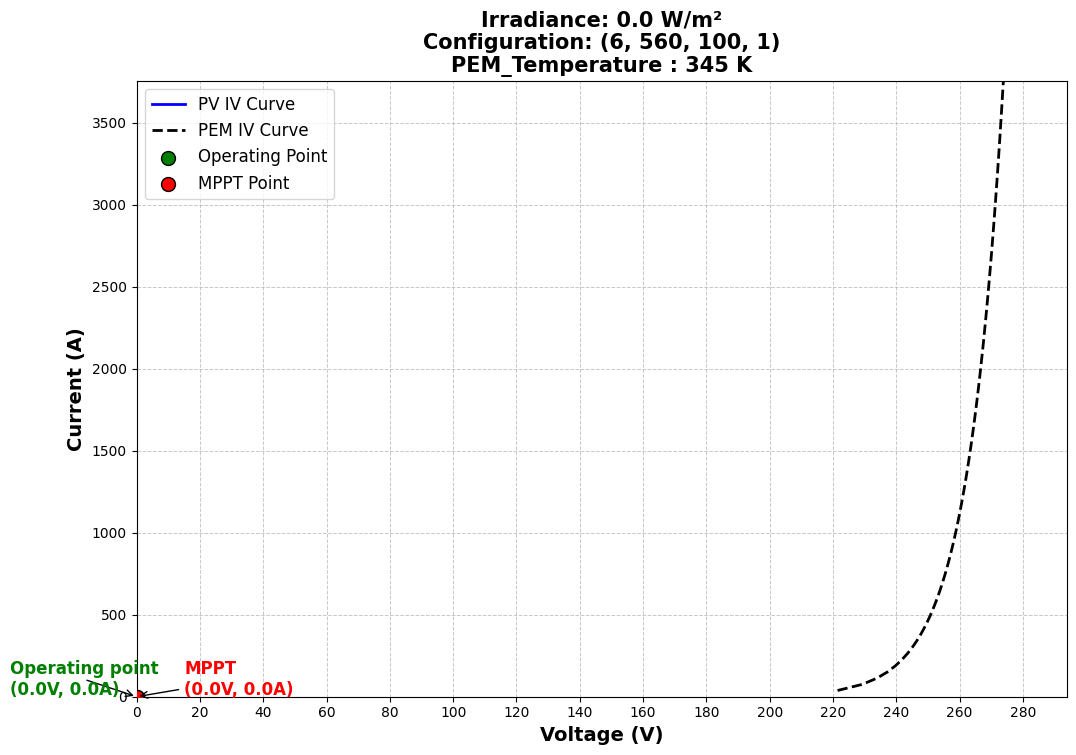

----------------------------------------------------------------------------------
⚠️ Skipping optimization: Irradiance = 0.0 W/m² is below threshold.
In Day 1 and Hour 2 with average irradiance 0.0 W/m2 the best Configuration for direct coupling is: (6, 560, 100, 1, 0, 0, 0, 0, 345, 0, 0)

In Day 1 and Hour 2 the losses are 0
In Day 1 and Hour 2 the hydrogen production is 0


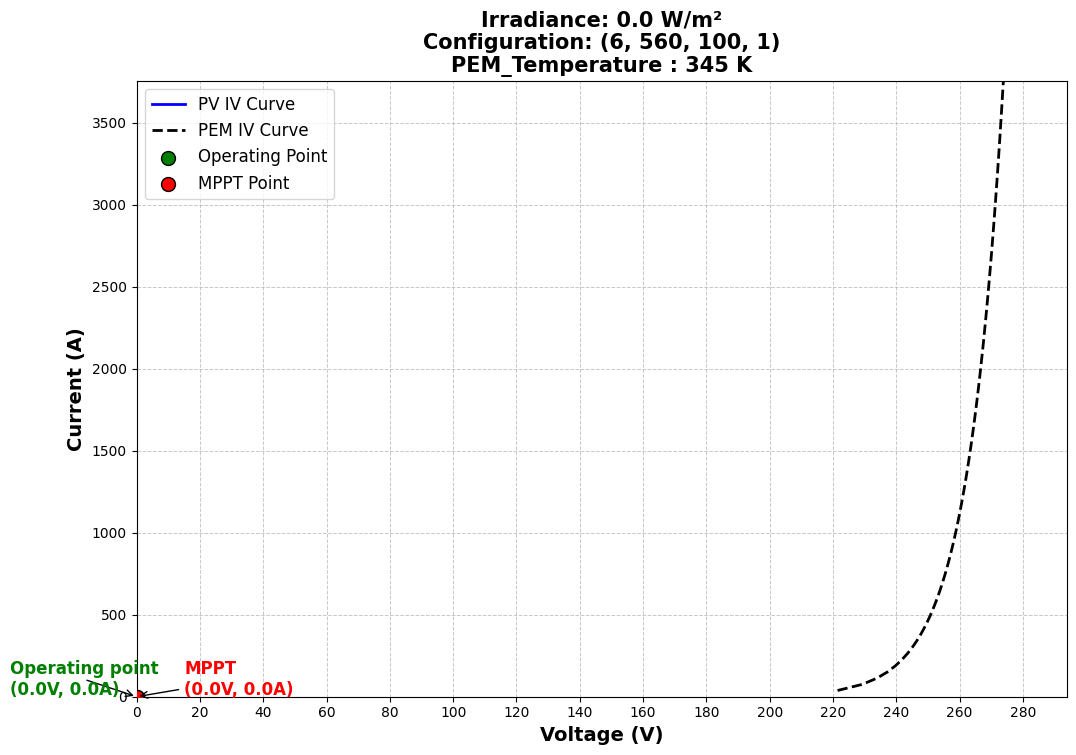

----------------------------------------------------------------------------------
⚠️ Skipping optimization: Irradiance = 0.0 W/m² is below threshold.
In Day 1 and Hour 3 with average irradiance 0.0 W/m2 the best Configuration for direct coupling is: (6, 560, 100, 1, 0, 0, 0, 0, 345, 0, 0)

In Day 1 and Hour 3 the losses are 0
In Day 1 and Hour 3 the hydrogen production is 0


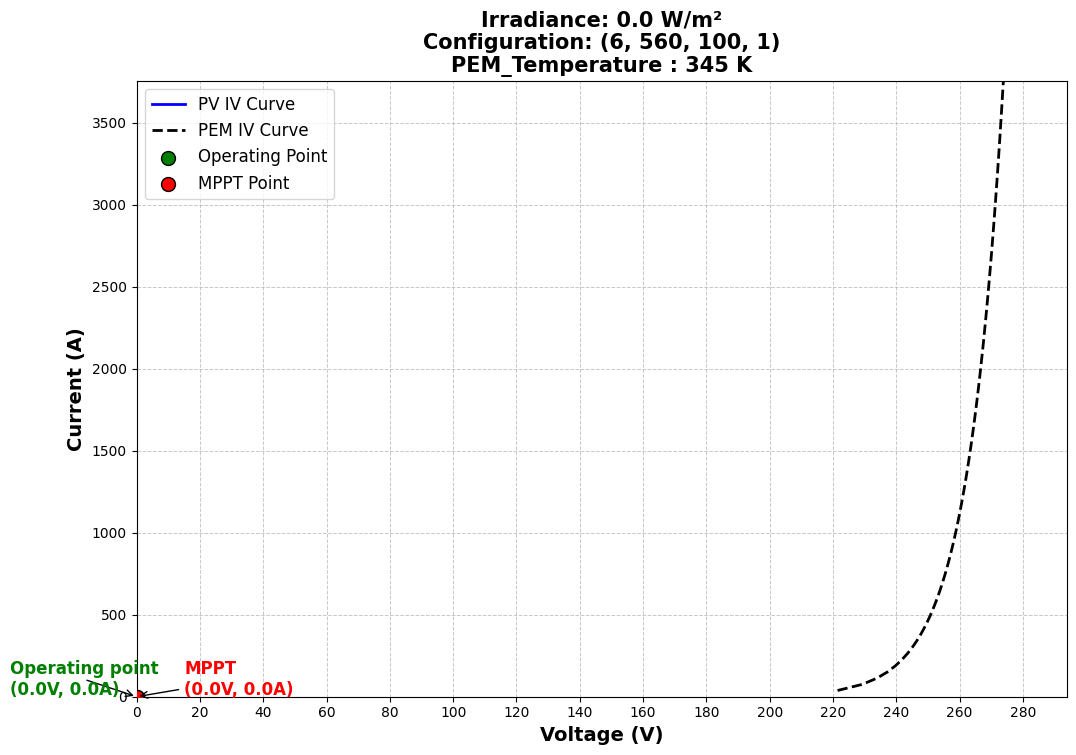

----------------------------------------------------------------------------------
⚠️ Skipping optimization: Irradiance = 0.0 W/m² is below threshold.
In Day 1 and Hour 4 with average irradiance 0.0 W/m2 the best Configuration for direct coupling is: (6, 560, 100, 1, 0, 0, 0, 0, 345, 0, 0)

In Day 1 and Hour 4 the losses are 0
In Day 1 and Hour 4 the hydrogen production is 0


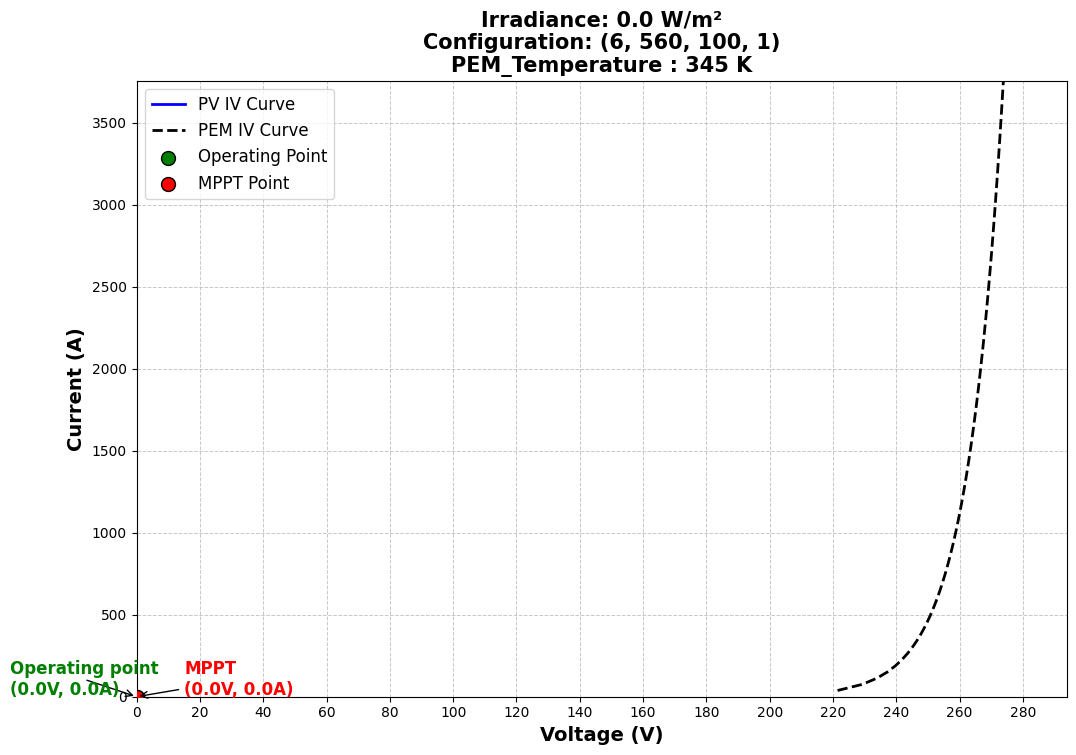

----------------------------------------------------------------------------------
⚠️ Skipping optimization: Irradiance = 0.0 W/m² is below threshold.
In Day 1 and Hour 5 with average irradiance 0.0 W/m2 the best Configuration for direct coupling is: (6, 560, 100, 1, 0, 0, 0, 0, 345, 0, 0)

In Day 1 and Hour 5 the losses are 0
In Day 1 and Hour 5 the hydrogen production is 0


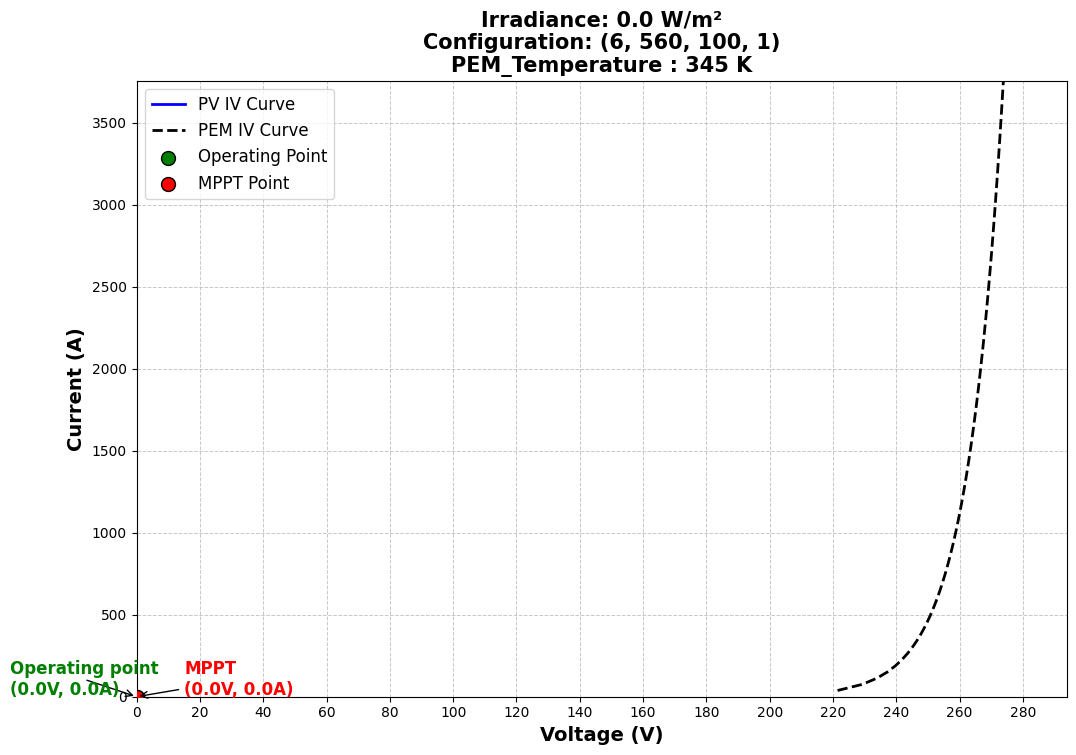

----------------------------------------------------------------------------------
⚠️ Skipping optimization: Irradiance = 0.0 W/m² is below threshold.
In Day 1 and Hour 6 with average irradiance 0.0 W/m2 the best Configuration for direct coupling is: (6, 560, 100, 1, 0, 0, 0, 0, 345, 0, 0)

In Day 1 and Hour 6 the losses are 0
In Day 1 and Hour 6 the hydrogen production is 0


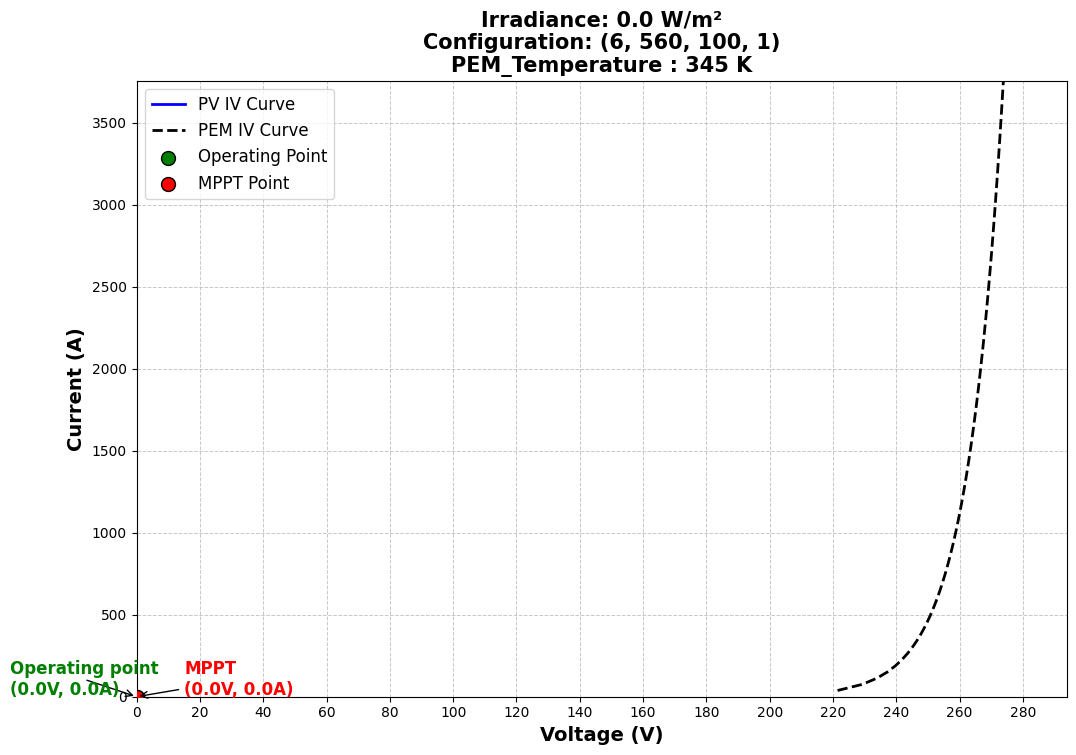

----------------------------------------------------------------------------------
⚠️ Skipping optimization: Irradiance = 0.0 W/m² is below threshold.
In Day 1 and Hour 7 with average irradiance 0.0 W/m2 the best Configuration for direct coupling is: (6, 560, 100, 1, 0, 0, 0, 0, 345, 0, 0)

In Day 1 and Hour 7 the losses are 0
In Day 1 and Hour 7 the hydrogen production is 0


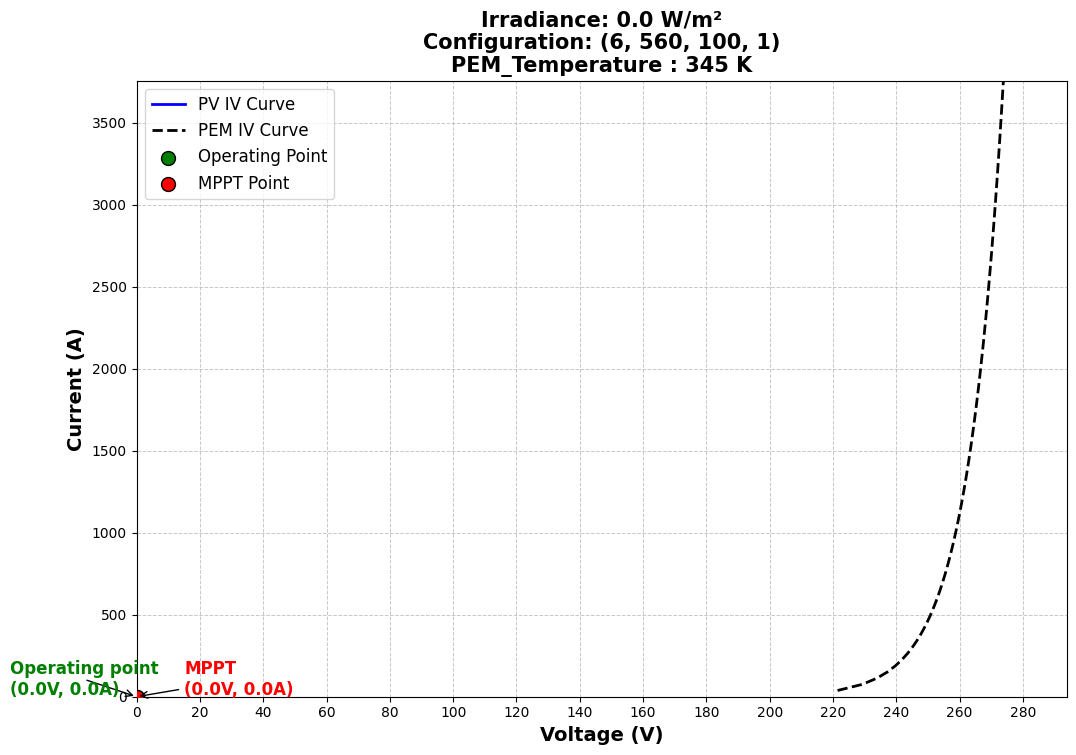

----------------------------------------------------------------------------------
⚠️ Skipping optimization: Irradiance = 0.0 W/m² is below threshold.
In Day 1 and Hour 8 with average irradiance 0.0 W/m2 the best Configuration for direct coupling is: (6, 560, 100, 1, 0, 0, 0, 0, 345, 0, 0)

In Day 1 and Hour 8 the losses are 0
In Day 1 and Hour 8 the hydrogen production is 0


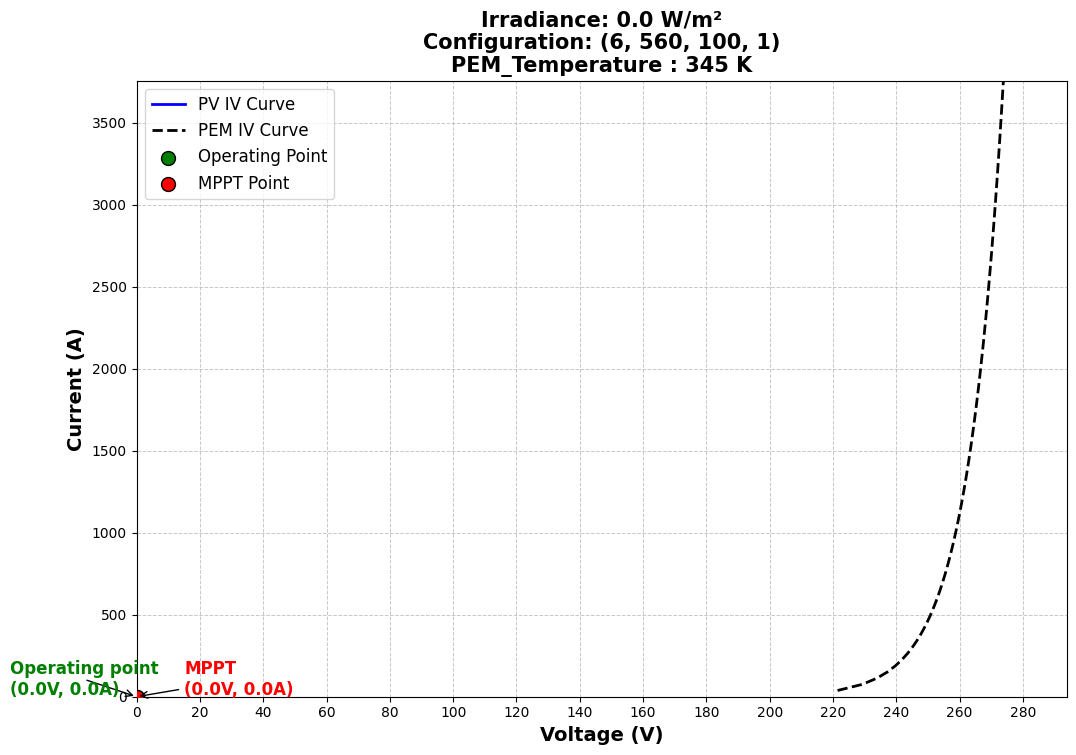

----------------------------------------------------------------------------------
⚠️ Skipping optimization: Irradiance = 20.25 W/m² is below threshold.
In Day 1 and Hour 9 with average irradiance 20.25 W/m2 the best Configuration for direct coupling is: (6, 560, 100, 1, 0, 0, 0, 0, 345, 0, 0)

In Day 1 and Hour 9 the losses are 0
In Day 1 and Hour 9 the hydrogen production is 0


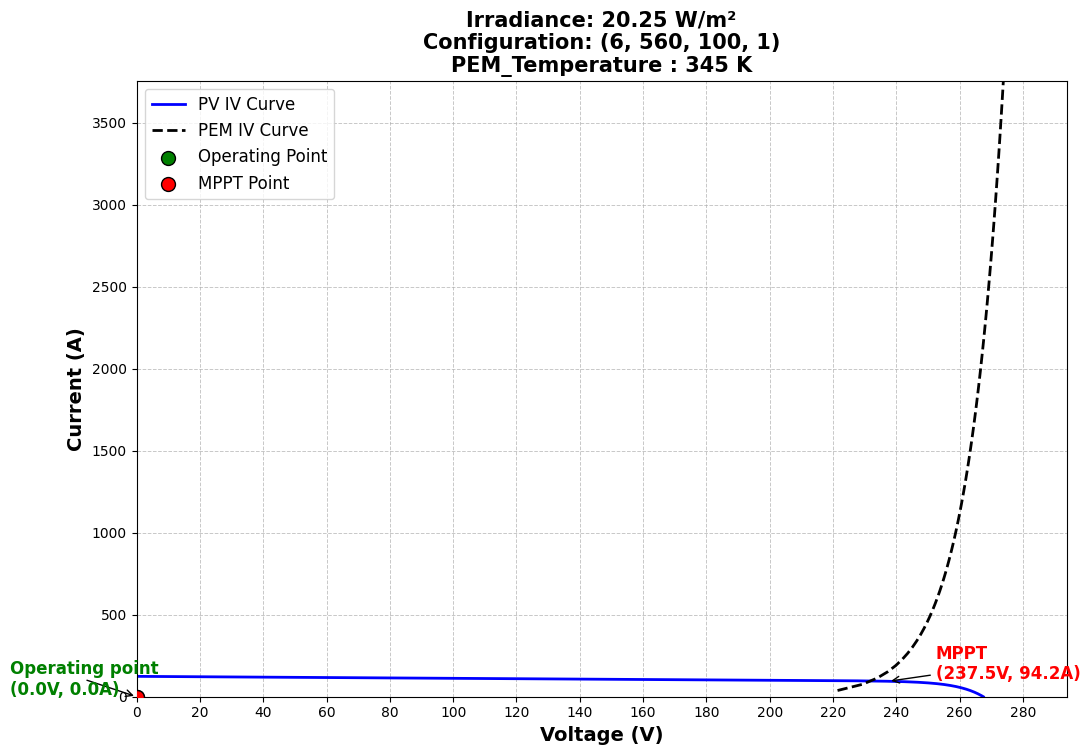

----------------------------------------------------------------------------------
⚠️ Skipping optimization: Irradiance = 49.31 W/m² is below threshold.
In Day 1 and Hour 10 with average irradiance 49.31 W/m2 the best Configuration for direct coupling is: (6, 560, 100, 1, 0, 0, 0, 0, 345, 0, 0)

In Day 1 and Hour 10 the losses are 0
In Day 1 and Hour 10 the hydrogen production is 0


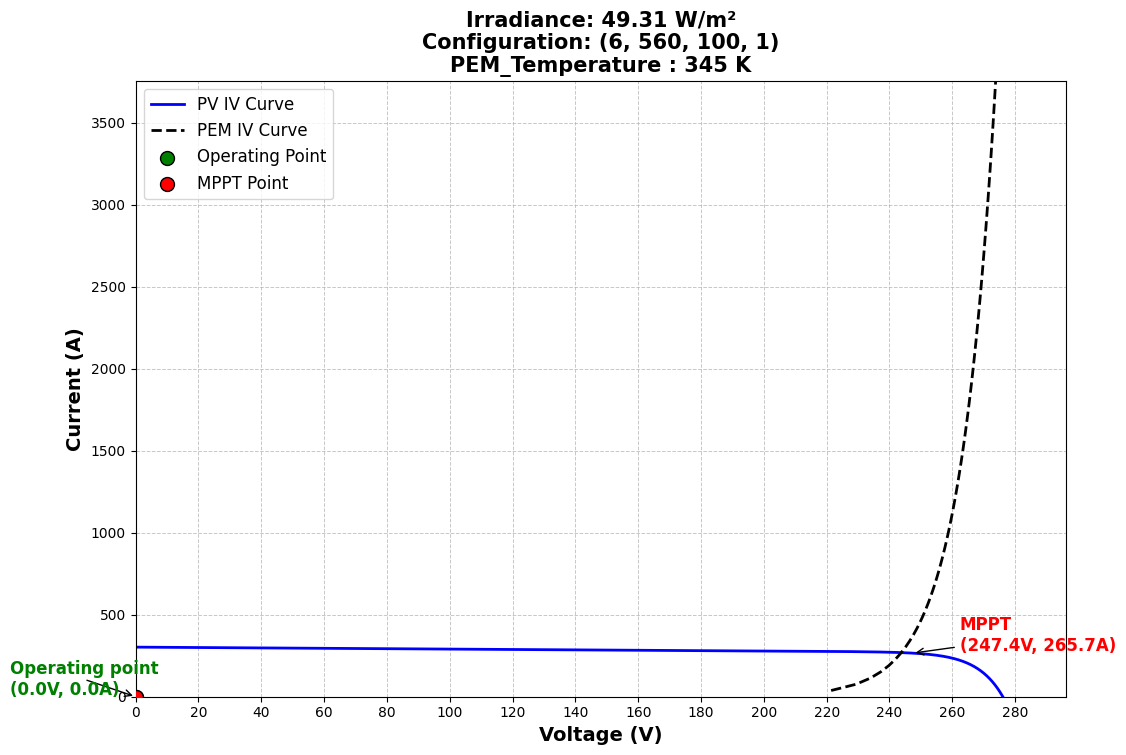

----------------------------------------------------------------------------------
🔧 Performing full optimization...

=== Evaluating PEM temperature: 345 K ===
In Day 1 and Hour 11 the energy loss is 402.7547973653709
In Day 1 and Hour 11 and num_modules_parallel =288 the mppt_distance is 402.7547973653709 
Fractional load: 1.00, Production efficiency: 0.65, Hydrogen production: 1.5021 kg
In Day 1 and Hour 11, num_modules_parallel=288 - hydrogen production: 1.50, potential storage: 111.50
In Day 1 and Hour 11 and num_modules_parallel =288 the electrical efficiency is 0.9947934088381076
-------------------------------------------------------------
CAPEX is: 2292680 Euros
The score is -0.16277444548029096
-----------------------------------------------------------------------------------------
In Day 1 and Hour 11 the energy loss is 173.26990442315582
In Day 1 and Hour 11 and num_modules_parallel =324 the mppt_distance is 173.26990442315582 
Fractional load: 1.00, Production efficiency: 

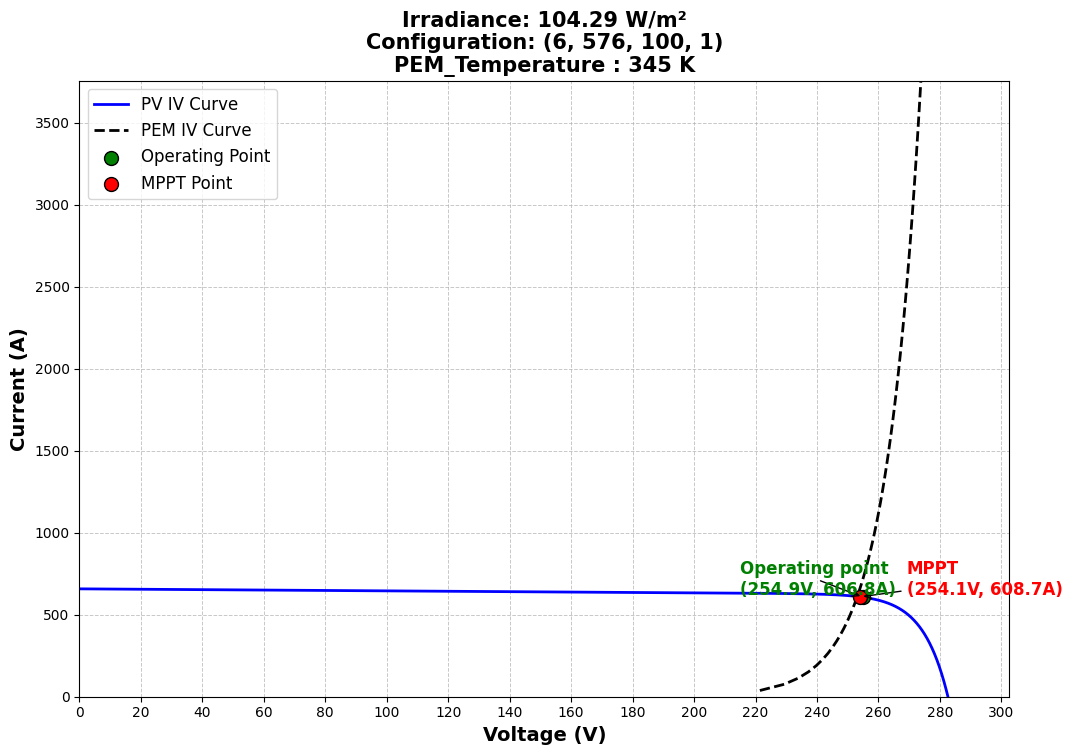

----------------------------------------------------------------------------------
🔧 Performing full optimization...

=== Evaluating PEM temperature: 345 K ===
In Day 1 and Hour 12 the energy loss is 1380.8063062570582
In Day 1 and Hour 12 and num_modules_parallel =288 the mppt_distance is 1380.8063062570582 
Fractional load: 0.82, Production efficiency: 0.69, Hydrogen production: 1.2625 kg
In Day 1 and Hour 12, num_modules_parallel=288 - hydrogen production: 1.26, potential storage: 111.26
In Day 1 and Hour 12 and num_modules_parallel =288 the electrical efficiency is 0.9779407208823557
-------------------------------------------------------------
CAPEX is: 2292680 Euros
The score is -0.1433084871729176
-----------------------------------------------------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#------------------------------------------------------------
start_time = time.time()

def find_intersection_point(voltages_pv, currents_pv, voltages_pem, currents_pem):
    """
    Find the closest intersection point between PV and PEM voltage-current characteristics.
    """
    min_error = float('inf')
    best_point = None

    for v_pv, i_pv in zip(voltages_pv, currents_pv):
        for v_pem, i_pem in zip(voltages_pem, currents_pem):
            error = np.sqrt((v_pv - v_pem)**2 + (i_pv - i_pem)**2)  # Euclidean distance
            if error < min_error:
                min_error = error
                best_point = (v_pv, i_pv)

    return best_point  # Closest match


full_optimization_count = 0
prediction_used_count = 0
hourly_hydrogen_target = 5
storage_capacity = 10000

# Combined Optimization Routine
def optimize_pv_and_pem_configuration(params, irradiance, p_cat, p_an, δ_mem, A_cell, a_an, a_cat, i_0_an, i_0_cat, T_ref, i_lim,
                                      weight_mppt=0.308, weight_StH=0.101, weight_econ=0, storage_capacity=10000):
    global full_optimization_count, prediction_used_count

    # 🛑 Skip if irradiance is too low
    if irradiance < 80:
        print(f"⚠️ Skipping optimization: Irradiance = {irradiance} W/m² is below threshold.")
        return (
            6,   # num_modules_series
            560,  # num_modules_parallel
            100,  # num_cell_series
            1,   # num_cell_parallel
            0,   # operating_voltage
            0,   # operating_current
            0,   # mppt_voltage
            0,   # mppt_current
            345,   # PEM_temperature
            0,   # hydrogen_production
            0    # StH_efficiency
         )


    input_features = [irradiance, temperature]  # Add more input features if needed

    predicted_config = predict_configuration(input_features)
    if predicted_config is not None:
        prediction_used_count += 1
        print("🧠 Using predicted configuration:", predicted_config)
        return predicted_config

    # If no valid prediction, do full optimization
    full_optimization_count += 1
    print("🔧 Performing full optimization...")

    best_configuration = None
    best_score = float('inf')  # Lower score is better
    closest_to_mppt = float('inf')
    highest_hydrogen_production = 0
    mppt_voltage, mppt_current = 0, 0

    # 🔁 Loop over PEM operating temperature
    for T in range(345, 356, 10):  # 320 K to 360 K inclusive, step of 10
        print(f"\n=== Evaluating PEM temperature: {T} K ===")

      # Iterate through possible configurations
        for num_modules_series in range(6, 7):  # Adjust as needed
            for num_modules_parallel in range(288,577,36):  # Adjust as needed
                effective_irradiance = calculate_effective_irradiance(irradiance,0.1*irradiance, tilt_angle_deg, sun_zenith_deg)
                voltages, currents, powers, mppt_index = perturb_observe_series(
                params_with_temp, effective_irradiance, num_modules_series=num_modules_series, num_modules_parallel=num_modules_parallel)
                mppt_voltage, mppt_current, _ = find_mppt(voltages, currents)
                stored_hydrogen = 0  # Initialize stored hydrogen for the day
                total_stored_hydrogen = 0


                for num_cell_series in range(100, 101):  # Adjust as needed
                    for num_cell_parallel in range(1, 2):  # Adjust as needed
                        # Initialize stored_hydrogen for each configuration iteration
                        stored_hydrogen = 115 # Initialize with a starting value or load from a persistent source if needed

                        pem_currents = np.linspace(0, I_PEM(i_cell, num_cell_parallel), 100)

                        pem_voltages = [V_PEM(T, p_cat, p_an, δ_mem, A_cell, a_an, a_cat, i, i_0_an, i_0_cat, T_ref, i_lim, num_cell_series) for i in pem_currents]

                        # Find the best match between PV and PEM operation
                        best_point = find_intersection_point(voltages, currents, pem_voltages, pem_currents)

                        if best_point:
                            operating_voltage, operating_current = best_point
                        else:
                            continue  # Skip this iteration if no intersection found

                        voltage_difference = abs(operating_voltage - V_PEM(T, p_cat, p_an, δ_mem, A_cell, a_an, a_cat,
                                                                              operating_current, i_0_an, i_0_cat, T_ref,
                                                                              i_lim, num_cell_series))
                        current_difference = abs(operating_current - I_PEM(operating_current, num_cell_parallel))
                        total_difference = voltage_difference + current_difference
                        distance_to_mppt = abs(mppt_voltage*mppt_current - operating_voltage * operating_current)
                        #np.sqrt(voltage_difference**2 + current_difference**2)

                        print(f'In Day {day} and Hour {hour} the energy loss is {distance_to_mppt}')

                        # Inside your loop where hydrogen_production is calculated
                        fractional_load = (operating_voltage * operating_current) / PEM_capacity

                        # Clip fractional load between 0 and 1 to avoid extrapolation
                        fractional_load = np.clip(fractional_load, 0, 1)

                        # Get the production efficiency from the piecewise curve
                        production_efficiency = np.interp(fractional_load, load_points, efficiency_points)

                        if  mppt_current >  np.max(pem_currents) or irradiance < 80:
                            hydrogen_production=0
                        else:
                            hydrogen_production = (operating_voltage * operating_current * production_efficiency) / (LHV)


                        print(f'In Day {day} and Hour {hour} and num_modules_parallel ={num_modules_parallel} the mppt_distance is {distance_to_mppt} ')
                        print(f"Fractional load: {fractional_load:.2f}, Production efficiency: {production_efficiency:.2f}, Hydrogen production: {hydrogen_production:.4f} kg")

                        # ⚠️ Demand exists even if no production
                        net_hydrogen = hydrogen_production - hourly_hydrogen_target
                        potential_storage = stored_hydrogen + net_hydrogen

                        # Apply bounds to storage
                        if potential_storage > storage_capacity:
                            overflow = potential_storage - storage_capacity
                            hydrogen_loss_penalty = overflow
                            # Cap storage
                            stored_hydrogen = storage_capacity
                        elif potential_storage < 0:
                            hydrogen_loss_penalty = 0  # No production to waste, but we account for depletion
                            stored_hydrogen = potential_storage  # Let it go negative (shortage)
                        else:
                            hydrogen_loss_penalty = 0
                            stored_hydrogen = potential_storage


                        # Print for debugging
                        print(f'In Day {day} and Hour {hour}, num_modules_parallel={num_modules_parallel} - hydrogen production: {hydrogen_production:.2f}, potential storage: {potential_storage:.2f}')
                        #-----------------------------------------------------------------------

                        #Electrical Efficiency
                        if  mppt_current >  np.max(pem_currents) or irradiance < 80:
                            el_efficiency=0
                        else:
                            el_efficiency = (( operating_voltage* operating_current) / (mppt_voltage*mppt_current))
                        print(f'In Day {day} and Hour {hour} and num_modules_parallel ={num_modules_parallel} the electrical efficiency is {el_efficiency}')
                        print('-------------------------------------------------------------')

                        # Calculate the area
                        pv_area = num_modules_series * num_modules_parallel * module_area
                        pem_area = num_cell_series * num_cell_parallel * A_cell / 1000

                        #StH efficiency
                        if  mppt_current >  np.max(pem_currents) or irradiance < 80:
                            StH_efficiency=0
                        else:
                            StH_efficiency = (hydrogen_production*LHV)/(irradiance * pv_area)

                        # Example economic parameters (you can adjust based on real data)
                        cost_per_pv_module = 310      # $ per PV module (700/kW -> )
                        cost_per_pem_cell = 17570        # $ per PEM cell (1800eur/kW -> )


                        # Calculate economic objective
                        pv_area = num_modules_series * num_modules_parallel * module_area
                        pem_area = num_cell_series * num_cell_parallel * A_cell / 1000  # m²

                        pv_cost = cost_per_pv_module * num_modules_series * num_modules_parallel
                        pem_cost = cost_per_pem_cell * num_cell_series * num_cell_parallel
                        total_capex = pv_cost + pem_cost
                        print(f'CAPEX is:',total_capex, 'Euros')
                        #capex_per_hour=total_capex / (25*8760)
                        #print(f'CAPEX_per_hour is:', capex_per_hour,'Euros/kg')
                        #print(f'Hydrogen production is:', hydrogen_production)


                        # Normalize economic objective (for example, divide by max expected CAPEX to get 0-1 scale)
                        capex_norm = total_capex/ 57000   # adjust 50000 to realistic max cost
                        hydrogen_production_norm = hydrogen_production / 20
                        StH_efficiency_norm = StH_efficiency /  0.15
                        distance_to_mppt_norm = distance_to_mppt / 20000

                        if not np.isnan(distance_to_mppt) and not np.isinf(distance_to_mppt):
                            score = (
                                -(1-weight_StH-weight_mppt-weight_econ) * hydrogen_production_norm -
                                weight_StH * StH_efficiency_norm +
                                weight_mppt * distance_to_mppt_norm + weight_econ * capex_norm
                            )
                        else:
                            score = -np.inf  # or a very low score to skip invalid case

                        print(f'The score is {score}')
                        print('-----------------------------------------------------------------------------------------')


                        if score < best_score:
                                best_score = score
                                closest_to_mppt = distance_to_mppt
                                highest_hydrogen_production = hydrogen_production
                                best_configuration = (

                                    num_modules_series, num_modules_parallel,
                                    num_cell_series, num_cell_parallel,
                                    operating_voltage, operating_current,
                                    mppt_voltage, mppt_current,T,  # ✅ include temperature in best configuration
                                    hydrogen_production, StH_efficiency
                                )


    if best_configuration is None:
                    print(f'In Day {day} and Hour {hour} with irradiance {irradiance} W/m2 the best Configuration for direct coupling is: None\n')
                    num_modules_series, num_modules_parallel, num_cell_series, num_cell_parallel, operating_voltage, operating_current, mppt_voltage, mppt_current,T,hydrogen_production, StH_efficiency = 6,560,100,1,0,0,0,0,345,0,0

    # Save and train on best configuration if found
    if best_configuration is not None:
        save_training_data(input_features, best_configuration)
        train_model()

    return best_configuration



time_resolution = 60 * 60 # in sec

# Initialize variables to track the maximum configurations
max_num_modules_series = 0
max_num_modules_parallel = 0
max_num_cell_series = 0
max_num_cell_parallel = 0
el_efficiency=0
StH_efficiency=0


# Read irradiance values from Excel file
df_irradiance = pd.read_excel('Irradiance_values_example.xlsx','Lund_2021')

# Initialize an empty list to store all results
all_results_flex = []

# Group the data by day
grouped = df_irradiance.groupby('Day')

avg_pv_series_days= []
avg_pv_parallel_days=[]
avg_pem_series_days= []
avg_pem_parallel_days = []
avg_pv_area_days = []
avg_pem_area_days = []

max_pv_series_days= []
max_pv_parallel_days=[]
max_pem_series_days= []
max_pem_parallel_days = []
max_pv_area_days = []
max_pem_area_days=[]

total_capex_days = 0
total_losses_days = 0
total_hydrogen_production_days= 0
storage_capacity = 10000  # example in kg or kWh – set according to your case
stored_hydrogen = 115     # persistent across days

# Define pv_module_area here
pv_module_area = 1.5 # m^2


# Iterate through each day
for day, group in grouped:
    hours_values = group['Hour'].tolist()
    hourly_averaged_irradiance_values = group['Irradiance_Lund'].tolist()
    hourly_averaged_temperature_values = group['Temperature_Lund'].tolist()

    irradiance_temperature_mapping = [
        {'hour': hour, 'irradiance': irr, 'temperature': temp}
        for hour, irr, temp in zip(hours_values, hourly_averaged_irradiance_values, hourly_averaged_temperature_values)
    ]

    results_flex = []
    total_losses = 0
    total_pv_series = 0
    total_pv_parallel = 0
    total_pem_series = 0
    total_pem_parallel = 0
    total_hydrogen_production = 0
    total_losses_configuration = 0
    total_capex = 0
    #stored_hydrogen = 0
    #total_stored_hydrogen=0

    # Iterate through each hour of the day
    for entry in irradiance_temperature_mapping:
        hour = entry['hour']
        irradiance = entry['irradiance']
        temperature = entry['temperature']

        # Initialize variables with default values for each hour
        num_modules_series, num_modules_parallel, num_cell_series, num_cell_parallel = 0, 0, 0, 0
        operating_voltage, operating_current, mppt_voltage, mppt_current = 0, 0, 0, 0
        T, hydrogen_production, StH_efficiency, el_efficiency = 345, 0, 0, 0
        hour_losses = 0
        pv_area = 0
        pem_area = 0
        CAPEX = 0
        net_hydrogen = 0
        #stored_hydrogen = 0 # This should not be re-initialized every hour


        params_with_temp = params_base + [temperature]
        best_configuration = optimize_pv_and_pem_configuration(params_with_temp, irradiance, p_cat, p_an, δ_mem, A_cell, a_an, a_cat, i_0_an, i_0_cat,
                                                               T_ref, i_lim,weight_mppt=0.308, weight_StH=0.101, weight_econ=0 ,storage_capacity=5000)
        if best_configuration is  None:
            num_modules_series, num_modules_parallel, num_cell_series, num_cell_parallel, operating_voltage, operating_current, mppt_voltage, mppt_current,T,hydrogen_production, StH_efficiency = 8,560,100,1,0,0,0,0,345,0,0
            net_hydrogen = hydrogen_production - hourly_hydrogen_target
            potential_storage = stored_hydrogen + net_hydrogen
            stored_hydrogen = potential_storage

        if best_configuration is not None and len(best_configuration) == 11:
            (num_modules_series, num_modules_parallel,
             num_cell_series, num_cell_parallel,
             operating_voltage, operating_current,
             mppt_voltage, mppt_current,T,
             hydrogen_production, StH_efficiency) = best_configuration

            print(f'In Day {day} and Hour {hour} with average irradiance {irradiance} W/m2 the best Configuration for direct coupling is: {best_configuration}\n')


            # Calculate losses for this hour
            hour_losses = mppt_voltage * mppt_current - operating_voltage * operating_current
            print(f'In Day {day} and Hour {hour} the losses are {hour_losses}')

            # Generate IV curves for PV
            effective_irradiance = calculate_effective_irradiance(irradiance,0.1*irradiance, tilt_angle_deg, sun_zenith_deg)
            voltages, currents, powers, mppt_index = perturb_observe_series(
              params_with_temp, effective_irradiance, num_modules_series=num_modules_series, num_modules_parallel=num_modules_parallel)

            # Generate IV curve for PEM
            current_range_pem = np.linspace(0, I_PEM(i_cell, num_cell_parallel), 100) # i_cell!!!!!!
            voltages_pem = [V_PEM(T, p_cat, p_an, δ_mem, A_cell, a_an, a_cat, current, i_0_an, i_0_cat, T_ref, i_lim, num_cell_series) for current in current_range_pem]

            # Calculate hydrogen production

            if  mppt_current >  np.max(current_range_pem) or irradiance < 80:
                hydrogen_production=0
            else:
                hydrogen_production = (operating_voltage * operating_current * efficiency) / (LHV)
            print(f'In Day {day} and Hour {hour} the hydrogen production is {hydrogen_production}')

            net_hydrogen = hydrogen_production - hourly_hydrogen_target
            potential_storage = stored_hydrogen + net_hydrogen

            # Adjust hydrogen production to avoid overflow if necessary
            if potential_storage > storage_capacity:
                overflow = potential_storage - storage_capacity
                hydrogen_loss_penalty = overflow

                # Adjust hydrogen production to only meet available storage space
                allowed_net_hydrogen = storage_capacity - stored_hydrogen
                if hydrogen_production > hourly_hydrogen_target:
                    hydrogen_production = hourly_hydrogen_target + max(0, allowed_net_hydrogen)

                stored_hydrogen = storage_capacity
            else:
                hydrogen_loss_penalty = 0
                stored_hydrogen = potential_storage

            #Electrical Efficiency
            if  mppt_current >  np.max(current_range_pem)  or irradiance < 80:
                el_efficiency=0
            else:
                el_efficiency = (( operating_voltage* operating_current) / (mppt_voltage*mppt_current))

            # Calculate the area
            pv_area = num_modules_series * num_modules_parallel * module_area
            pem_area = num_cell_series * num_cell_parallel * A_cell / 1000

            #StH efficiency
            if  mppt_current >  np.max(current_range_pem)  or irradiance < 80:
                StH_efficiency=0
            else:
                StH_efficiency = (hydrogen_production*LHV)/(irradiance * pv_area)



            # Track the maximum values
            max_num_modules_series = max(max_num_modules_series, num_modules_series)
            max_num_modules_parallel = max(max_num_modules_parallel, num_modules_parallel)
            max_num_cell_series = max(max_num_cell_series, num_cell_series)
            max_num_cell_parallel = max(max_num_cell_parallel, num_cell_parallel)

            # Create the figure and axis
            plt.figure(figsize=(12, 8))

            # Plot IV Curves
            plt.plot(np.array(voltages), np.array(currents), 'b-', linewidth=2, label='PV IV Curve')
            plt.plot(voltages_pem, current_range_pem, '--', color='black', linewidth=2, label='PEM IV Curve')

            # Highlight Operating Point and MPPT Point
            plt.scatter(operating_voltage, operating_current, color='green', s=100, edgecolors='black', zorder=3, label='Operating Point')
            plt.scatter(mppt_voltage, mppt_current, color='red', s=100, edgecolors='black', zorder=3, label='MPPT Point')


            # Annotate Important Points
            plt.annotate(f"MPPT\n({voltages[mppt_index]:.1f}V, {currents[mppt_index]:.1f}A)",
                          xy=(voltages[mppt_index], currents[mppt_index]),
                          xytext=(voltages[mppt_index] + 15, currents[mppt_index] + 12),
                          arrowprops=dict(arrowstyle="->", color='black'),
                          fontsize=12, color='red', weight='bold')

            plt.annotate(f"Operating point\n({operating_voltage:.1f}V, {operating_current:.1f}A)",
                          xy=(operating_voltage, operating_current),
                          xytext=(operating_voltage - 40, operating_current + 12),
                          arrowprops=dict(arrowstyle="->", color='black'),
                          fontsize=12, color='green', weight='bold')

            # Set axis limits dynamically
            x_max = max(max(np.array(voltages)), max(voltages_pem)) + 20
            plt.xlim(0, x_max)

            # Set x-axis ticks every 20 units
            plt.xticks(np.arange(0, x_max + 1, 20))
            plt.ylim(0, max(max(np.array(currents)), max(current_range_pem)) + 5)

            ## Labels and Title
            plt.xlabel('Voltage (V)', fontsize=14, fontweight='bold')
            plt.ylabel('Current (A)', fontsize=14, fontweight='bold')
            plt.title(f'Irradiance: {irradiance} W/m²\n'
              f'Configuration: ({num_modules_series}, {num_modules_parallel}, {num_cell_series}, {num_cell_parallel})\n'
              f'PEM_Temperature : {T} K',
              fontsize=15, fontweight='bold')
                      #Day {day}, Hour {hour}, Avg Irradiance {irradiance} W/m²', fontsize=15, fontweight='bold')

            # Improve grid and legend
            plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
            plt.legend(fontsize=12, loc='upper left', frameon=True)

            # Show plot
            plt.show()

            # Append the results to the list

            # PV capex 0.57-1 eur/W
            CAPEX_PV = 0.7*mppt_voltage*mppt_current #Euro
            CAPEX_EZ = 0.89*i_cell* num_cell_parallel*V_PEM(T, p_cat, p_an, δ_mem, A_cell, a_an, a_cat, current_range_pem, i_0_an, i_0_cat, T_ref, i_lim, num_cell_series)
            # PV Opex 23.17 eur/kW
            #OM_PV = CAPEX_PV*0.02 #Euro/year
            #OM_EZ = CAPEX_EZ*0.02 #Euro/year
            CAPEX = CAPEX_PV+CAPEX_EZ
            #TotalOM = OM_PV+OM_EZ


            # Update cumulative losses
            total_losses += hour_losses
            # Update cumulative configuration values
            total_pv_series += (num_modules_series)
            total_pv_parallel +=(num_modules_parallel)
            total_pem_series += (num_cell_series)
            total_pem_parallel += (num_cell_parallel)
            total_hydrogen_production += hydrogen_production
            total_capex += CAPEX


            #print(f'Total CAPEX for the installation in Day {day} is : {total_capex}')

            print('----------------------------------------------------------------------------------')


          # Append the results to the list
            results_flex.append([day,hour, irradiance, num_modules_series, num_modules_parallel, num_cell_series, num_cell_parallel, mppt_voltage,mppt_current,operating_voltage, operating_current,T,
                                 hydrogen_production, (pv_module_area * num_modules_series * num_modules_parallel), (A_cell * num_cell_series * num_cell_parallel / 10000),el_efficiency,StH_efficiency, net_hydrogen,stored_hydrogen])


    # Print total losses for the entire day
    print(f'Total direct coupling losses for the day {day}: {total_losses:.2f} W')

    # Custom rounding function
    def custom_round(value):
        return int(value) + 1 if 0 < (value - int(value)) <= 0.5 else round(value)


    # Calculate averages excluding hours with zero irradiance
    non_zero_irradiance_indices = [i for i, irradiance in enumerate(hourly_averaged_irradiance_values) if irradiance >= 80]


    print("len(non_zero_irradiance_indices):", len(non_zero_irradiance_indices))

    # Calculate averages excluding hours with zero irradiance
    if len(non_zero_irradiance_indices) > 0:
        avg_pv_series = round(total_pv_series / len(non_zero_irradiance_indices))

        # Calculate average PV modules in parallel
        avg_pv_parallel = round(total_pv_parallel / len(non_zero_irradiance_indices))

        # Calculate average PEM cells in series
        avg_pem_series = round(total_pem_series / len(non_zero_irradiance_indices))

        # Calculate average PEM cells in parallel
        avg_pem_parallel = custom_round(total_pem_parallel/ len(non_zero_irradiance_indices))

        avg_irradiance = sum(hourly_averaged_irradiance_values[i] for i in non_zero_irradiance_indices)/len(non_zero_irradiance_indices)

        # Print average configuration values
        print(f'Average Irradiance of the day {day} in no zero irradiance hour equal to : {avg_irradiance} W/m2')
        print(f'Average PV modules in series on day {day}: {avg_pv_series}')
        print(f'Average PV modules in parallel on day {day}: {avg_pv_parallel}')
        print(f'Average PEM cells in series on day {day}: {avg_pem_series}')
        print(f'Average PEM cells in parallel on day {day}: {avg_pem_parallel}')
    else:
        print(f"No hours with irradiance >= 80 W/m2 on day {day}")
        avg_pv_series = 0
        avg_pv_parallel = 0
        avg_pem_series = 0
        avg_pem_parallel = 0
        avg_irradiance = 0


    # Append results for this day to the list of all results
    all_results_flex.extend(results_flex)

    # Print the sum of hydrogen production for flexible configuration

    print(f'Total Hydrogen Production in Flexible Configuration for Day {day} is {total_hydrogen_production} kg')
    print('__________________________________________________________________________________________________________________________________________\n')

# Calculate average values for this day
    max_pv_series_days.append(max_num_modules_series)
    max_pv_parallel_days.append(max_num_modules_parallel)
    max_pem_series_days.append(max_num_cell_series)
    max_pem_parallel_days.append(max_num_cell_parallel)


# Calculate average values for this day
    avg_pv_series_days.append(avg_pv_series)
    avg_pv_parallel_days.append(avg_pv_parallel)
    avg_pem_series_days.append(avg_pem_series)
    avg_pem_parallel_days.append(avg_pem_parallel)

# Calcylate the capex
    total_capex_days += (total_capex)
    total_hydrogen_production_days += (total_hydrogen_production)
    total_losses_days += (total_losses)


# Calculate overall average of averages
avg_pv_series_days = (round(sum(avg_pv_series_days) / len(grouped)))
avg_pv_parallel_days = (round(sum(avg_pv_parallel_days) / len(grouped)))
avg_pem_series_days = (round(sum(avg_pem_series_days)) / len(grouped))
avg_pem_parallel_days = (round(sum(avg_pem_parallel_days))/ len(grouped))
avg_total_capex_days = np.mean(total_capex_days)

max_pv_series_days= custom_round(sum(max_pv_series_days) / len(grouped))
max_pv_parallel_days= custom_round(sum(max_pv_parallel_days) / len(grouped))
max_pem_series_days = custom_round(sum(max_pem_series_days) / len(grouped))
max_pem_parallel_days = custom_round (sum(max_pem_parallel_days) / len(grouped))
max_total_capex_days = np.max(total_capex_days)

print(f'The total losses with flexible configuration are : {total_losses_days} W')
print(f'The total hydrogen production with flexible configuration is : {total_hydrogen_production_days} kg')

print('-------------------------------------------------------------------------------------------------------------------------------------------------\n')

  # Rerun the code with the averaged configuration

average_configuration = (avg_pv_series_days, avg_pv_parallel_days, avg_pem_series_days, avg_pem_parallel_days)
print(f'The average configuration for all days is: {average_configuration}')

if np.isinf(avg_total_capex_days) or np.isnan(avg_total_capex_days):
    print("Warning: Invalid value detected. Assigning a fallback value.")
    avg_total_capex_days = 0  # or another reasonable fallback

print(f'The average capex for all days is: {round(avg_total_capex_days)} Euros')

max_configuration = (max_pv_series_days, max_pv_parallel_days, max_pem_series_days, max_pem_parallel_days)
print(f'The maximum configuration for all days is: {max_configuration}')

print(f'The maximum configuration for all days is: {round(max_total_capex_days)} Euros')


# Convert the list of all results to a DataFrame
df_flexible = pd.DataFrame(all_results_flex, columns=['Day', 'Hour', 'Average Irradiance (W/m2)', 'PV modules in Series', 'PV modules in Parallel', 'PEM Cell in Series', 'PEM Cell in Parallel', 'MPPT voltage','MPPT current',
                                                      'Operating Voltage', 'Operating Current','PEM_T', 'Hydrogen Production', 'PV Area', 'PEM Area','Electrical efficiency','StH_efficiency', 'Net','Hydrogen Stored/Disstored'])

# Save the DataFrame to an Excel file
df_flexible.to_excel('Direct_results_multi_ML.xlsx', index=False)

print(f"Full optimizations performed: {full_optimization_count}")
print(f"Predictions used: {prediction_used_count}")

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Execution time: {elapsed_time/60} mins")

In [ ]:
print(f"Full optimizations performed: {full_optimization_count}")
print(f"Predictions used: {prediction_used_count}")

In [ ]:
import pandas as pd
import numpy as np
import pickle
start_time = time.time()

# === 1. Load model ===
with open('config_predictor.pkl', 'rb') as f:
    model = pickle.load(f)

# === 2. Load forecast data from Excel ===
forecast_df = pd.read_excel('forecast_next_day.xlsx')
required_columns = ['Irradiance', 'Temperature']

# Check columns
if not set(required_columns).issubset(forecast_df.columns):
    raise ValueError(f"Excel file must contain the columns: {required_columns}")

# === 3. Prepare features ===
X_forecast = forecast_df[required_columns].copy()
X_forecast_scaled = X_forecast.values

# === 4. Apply conditional configuration ===
# Default prediction using model
predictions = model.predict(X_forecast_scaled)

# Replace predictions where Irradiance < 80
default_config = [8, 46, 90, 1, 0, 0, 0, 0, 340, 0, 0]  # Fixed configuration
irradiance_threshold = 80

# Iterate and replace low-irradiance predictions
for i, irr in enumerate(forecast_df['Irradiance']):
    if irr < irradiance_threshold:
        predictions[i] = default_config

# === 5. Create and save results ===
predicted_operation_df = pd.DataFrame(predictions.tolist(),
    columns=['num_modules_series', 'num_modules_parallel',
             'num_cell_series', 'num_cell_parallel',
             'operating_voltage', 'operating_current',
             'mppt_voltage', 'mppt_current','T',
             'hydrogen_production', 'StH_efficiency'])

# Floor num_modules_parallel as before
predicted_operation_df['num_modules_parallel'] = np.floor(predicted_operation_df['num_modules_parallel']).astype(int)

# Merge and save
forecast_df = pd.concat([forecast_df, predicted_operation_df], axis=1)
print(forecast_df)
forecast_df.to_excel('predicted_output_next_day.xlsx', index=False)

print("✅ Prediction completed. Results saved to 'predicted_output_next_day.xlsx'.")
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Execution time: {elapsed_time} secs")

    Day  Hour  Irradiance  Temperature  num_modules_series  \
0   367     1        0.00        11.16                 8.0   
1   367     2        0.00        10.51                 8.0   
2   367     3        0.00        10.61                 8.0   
3   367     4        0.00        10.45                 8.0   
4   367     5        0.00        10.27                 8.0   
5   367     6       38.92        10.26                 8.0   
6   367     7      149.35        11.78                 8.0   
7   367     8      361.75        13.65                 8.0   
8   367     9      568.93        15.86                 8.0   
9   367    10      774.53        17.49                 8.0   
10  367    11      927.73        18.89                 8.0   
11  367    12      900.00        19.73                 8.0   
12  367    13     1030.00        20.55                 8.0   
13  367    14      898.83        21.13                 8.0   
14  367    15      609.90        21.35                 8.0   
15  367 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Primary y-axis for Hydrogen Production
ax1 = plt.gca()
line1, = ax1.plot(forecast_df['hydrogen_production'], color='tab:blue', label='Hydrogen Production (kg)')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Hydrogen Production (kg)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Secondary y-axis for StH Efficiency
ax2 = ax1.twinx()
line2, = ax2.plot(forecast_df['StH_efficiency'], color='tab:orange', label='StH Efficiency (%)')
ax2.set_ylabel('StH Efficiency (%)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Title, grid, legend, layout
plt.title('Next Day Predicted Operation')
ax1.grid(True)

# Combine legends from both axes
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.savefig('forecast_plots.png')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#___________________Results Visualization and Correction______________________

# Step 1: Read the Excel file
df = pd.read_excel('Direct_results_multi_ML.xlsx', 'Sheet1')

# Step 2: Fix 0 values when Irradiance > 100
for i in range(1, len(df)):
    if df.loc[i, 'Average Irradiance (W/m2)'] > 100:
        if df.loc[i, 'Hydrogen Production'] == 0:
            df.loc[i, 'Hydrogen Production'] = df.loc[i - 1, 'Hydrogen Production']
        if df.loc[i, 'StH_efficiency'] == 0:
            df.loc[i, 'StH_efficiency'] = df.loc[i - 1, 'StH_efficiency']

# Optional: Save the corrected DataFrame back to Excel
df.to_excel('Direct_results_multi_ML_Lund_corrected.xlsx', index=False)

# Step 3: Sort by Irradiance (ascending)
df_sorted = df.sort_values(by='Average Irradiance (W/m2)')

# Step 4: Plot Irradiance vs PV modules in Parallel
plt.figure(figsize=(10, 6))
plt.plot(df_sorted['Average Irradiance (W/m2)'], df_sorted['PV modules in Parallel'], 'o-', label='PV modules in Parallel')
plt.xlabel('Average Irradiance (W/m²)')
plt.ylabel('PV Modules in Parallel')
plt.title('PV Modules in Parallel vs. Irradiance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Step 5: Plot Irradiance vs Hydrogen Production
plt.figure(figsize=(10, 6))
plt.plot(df_sorted['Average Irradiance (W/m2)'], df_sorted['Hydrogen Production'], 'o-', label='Hydrogen Production')
plt.xlabel('Average Irradiance (W/m²)')
plt.ylabel('Hydrogen Production')
plt.title('Hydrogen production vs. Irradiance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Step 6: Plot Irradiance vs StH Efficiency
plt.figure(figsize=(10, 6))
plt.plot(df_sorted['Average Irradiance (W/m2)'], df_sorted['StH_efficiency'], 'o-', label='StH Efficiency')
plt.xlabel('Average Irradiance (W/m²)')
plt.ylabel('StH Efficiency')
plt.title('StH_efficiency vs. Irradiance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Set a modern style
sns.set(style="whitegrid")

# Group irradiance by 50 W/m² bins (you have 50-step bins actually)
bin_edges = range(100, int(df['Average Irradiance (W/m2)'].max()) + 50, 50)
df['Irradiance Group'] = pd.cut(df['Average Irradiance (W/m2)'], bins=bin_edges, right=False)

# Calculate mean PV modules in parallel per group and round to nearest integer
grouped_df = df.groupby('Irradiance Group')['PV modules in Parallel'].mean().reset_index()
grouped_df['PV modules in Parallel'] = grouped_df['PV modules in Parallel'].round().astype(int)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Irradiance Group', y='PV modules in Parallel', data=grouped_df, palette='Blues_d')

# Add integer labels to the bars
for p in ax.patches:
    height = int(round(p.get_height()))
    ax.annotate(f"{height}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

# Set Y-axis ticks from 22 to 46 with step 6
plt.yticks(ticks=range(22, 47, 6))
plt.xticks(rotation=45)
plt.xlabel('Irradiance Range (W/m²)', fontsize=14)
plt.ylabel('PV Modules in Parallel', fontsize=14)
plt.title('Optimized Number of PV Panels Connected in Parallel per Irradiance in Lund,Sweden', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("Optimized PV in Lund.png", dpi=300)
plt.show()


# Calculate mean PV modules in parallel per group
grouped_df = df.groupby('Irradiance Group')['Hydrogen Production'].mean().reset_index()
# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Irradiance Group', y='Hydrogen Production', data=grouped_df, palette='Greens_d')
# Add labels to the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.xticks(rotation=45)
plt.xlabel('Irradiance Range (W/m²)',fontsize=14)
plt.ylabel(' Hydrogen Production (kg)', fontsize=14)
plt.title('Optimized Hydrogen Production per Irradiance in Lund,Sweden', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("Optimized Hydrogen Production in Lund.png", dpi=300)
plt.show()

# Calculate mean PV modules in parallel per group
grouped_df = df.groupby('Irradiance Group')['StH_efficiency'].mean().reset_index()
# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Irradiance Group', y='StH_efficiency', data=grouped_df, palette='Reds_d')
# Add labels to the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
# Set Y-axis ticks from 16 to 46 with step 6
plt.yticks(ticks=np.arange(0.13, 0.17, 0.01))
plt.xticks(rotation=45)
plt.xlabel('Irradiance Range (W/m²)',fontsize=14)
plt.ylabel(' StH efficiency ', fontsize=14)
plt.title('Optimized Solar-to-Hydrogen efficiency per Irradiance in Lund,Sweden', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("Optimized StH in Lund.png", dpi=300)
plt.show()